In [1]:
# import libraries

import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
# Initialize LabelEncoder
le = LabelEncoder()


%matplotlib inline

In [4]:
# Load data
import kagglehub
# Download latest version
path = kagglehub.dataset_download("computingvictor/transactions-fraud-datasets")

print("Path to dataset files:", path)
# Load CSV files
cards_data = pd.read_csv("/Users/m/.cache/kagglehub/datasets/computingvictor/transactions-fraud-datasets/versions/1/cards_data.csv")
transactions_data = pd.read_csv("/Users/m/.cache/kagglehub/datasets/computingvictor/transactions-fraud-datasets/versions/1/transactions_data.csv")
users_data = pd.read_csv("/Users/m/.cache/kagglehub/datasets/computingvictor/transactions-fraud-datasets/versions/1/users_data.csv")
# Load Json files
with open("/Users/m/.cache/kagglehub/datasets/computingvictor/transactions-fraud-datasets/versions/1/mcc_codes.json", "r") as f:
    mcc_codes = json.load(f)
with open("/Users/m/.cache/kagglehub/datasets/computingvictor/transactions-fraud-datasets/versions/1/train_fraud_labels.json", "r") as f:
    train_fraud_labels = json.load(f)


Path to dataset files: /Users/m/.cache/kagglehub/datasets/computingvictor/transactions-fraud-datasets/versions/1


In [5]:
# Performing data preparation on transactions_data

# convert the date column to date type object
transactions_data['date'] = pd.to_datetime(transactions_data['date'])

# convert date 
transactions_data['year'] = transactions_data['date'].dt.year
transactions_data['month'] = transactions_data['date'].dt.month
transactions_data['day'] = transactions_data['date'].dt.day
transactions_data['hour'] = transactions_data['date'].dt.hour
transactions_data['minute'] = transactions_data['date'].dt.minute

# getting the target dict from train_fraud_labels
target_dict = train_fraud_labels['target']
target_dict = {int(k):v for k,v in target_dict.items()}

# map the fraud_labels to transactions_data
transactions_data['target'] = transactions_data['id'].map(target_dict)

# convert the amount to numerical value
transactions_data['amount'] = transactions_data['amount'].replace('[\$,]', '', regex=True).astype('float')
# encode on the 'use_chip' column
transactions_data['use_chip_encoded'] = le.fit_transform(transactions_data['use_chip'])

# Fit and transform the 'merchant_id' column
transactions_data['merchant_id_encoded'] = le.fit_transform(transactions_data['merchant_id'])

# encode merchant city
transactions_data['merchant_city_encoded'] = le.fit_transform(transactions_data['merchant_city'])

# encode merchant state
transactions_data['merchant_state_encoded'] = le.fit_transform(transactions_data['merchant_state'])

# encode zip value
transactions_data['zip_encoded'] = le.fit_transform(transactions_data['zip'])

# encode mcc column
transactions_data['mcc_encoded'] = le.fit_transform(transactions_data['mcc'])
# encode errors column
transactions_data['errors_encoded'] = le.fit_transform(transactions_data['errors'])

# create a seperate df to hold mapping between merchant_id and merchant_id_encoded before dropping merchant_id
transactions_data_encode_mapping = transactions_data[['use_chip', 'use_chip_encoded', 'merchant_id', 'merchant_id_encoded', 'merchant_city', 'merchant_city_encoded', 'merchant_state', 'merchant_state_encoded', 'zip', 'zip_encoded', 'mcc', 'mcc_encoded', 'errors', 'errors_encoded']]

# Drop original columns which have been encoded
transactions_data = transactions_data.drop(columns=['use_chip', 'merchant_id', 'merchant_city', 'merchant_state', 'zip', 'mcc', 'errors', 'date'])

# update target with binary values 
binary_target = {'Yes': 1, 'No': 0}
transactions_data['target'] = transactions_data['target'].map(binary_target).fillna(-1).astype('int')

In [6]:
# Data preprocessing for cards_data

# Label encoding for 'card_brand', 'card_type' , 'has_chip' 'card_on_dark_web', 

# encoding for card_brand
cards_data['card_brand_encoded'] = le.fit_transform(cards_data['card_brand'])

# encoding for card_type
cards_data['card_type_encoded'] = le.fit_transform(cards_data['card_type'])

# encoding for card_number
cards_data['card_number_encoded'] = le.fit_transform(cards_data['card_number'])

# convert expires column to datetime format
cards_data['expires_formatted'] = pd.to_datetime(cards_data['expires'])

# convert expires column to year and month
cards_data['expires_year'] = cards_data['expires_formatted'].dt.year
cards_data['expires_month'] = cards_data['expires_formatted'].dt.month
# do label encoding for cvv, incase if some cvv are easier to guess
cards_data['cvv_encoded'] = le.fit_transform(cards_data['cvv'])

# label encoding for 'has_chip' column
cards_data['has_chip_encoded'] = le.fit_transform(cards_data['has_chip'])

# convert credit_limit column to float
cards_data['credit_limit'] = cards_data['credit_limit'].replace('[\$,]', '', regex=True).astype('float')

# convert expires column to datetime format
cards_data['acct_open_date_formatted'] = pd.to_datetime(cards_data['acct_open_date'])

# convert expires column to year and month
cards_data['acct_open_year'] = cards_data['acct_open_date_formatted'].dt.year
cards_data['acct_open_month'] = cards_data['acct_open_date_formatted'].dt.month

# label encoding for card_on_dark_web
cards_data['card_on_dark_web_encoded'] = le.fit_transform(cards_data['card_on_dark_web'])
# keeping the encoded mapping in a seperate df
cards_data_encode_mapping = cards_data[['card_brand', 'card_brand_encoded', 'card_type', 'card_type_encoded', 'card_number', 'card_number_encoded', 'cvv', 'cvv_encoded', 'has_chip', 'has_chip_encoded', 'card_on_dark_web', 'card_on_dark_web_encoded']]

# drop the original columns which have been encoded
cards_data = cards_data.drop(columns=['card_brand', 'card_type', 'card_number', 'expires', 'cvv', 'has_chip', 'acct_open_date', 'card_on_dark_web', 'expires_formatted', 'acct_open_date_formatted'])

In [7]:
cards_data.head()

,id,client_id,num_cards_issued,credit_limit,year_pin_last_changed,card_brand_encoded,card_type_encoded,card_number_encoded,expires_year,expires_month,cvv_encoded,has_chip_encoded,acct_open_year,acct_open_month,card_on_dark_web_encoded
0,4524,825,2,24295.0,2008,3,1,1212,2022,12,621,1,2002,9,0
1,2731,825,2,21968.0,2014,3,1,2611,2020,12,391,1,2014,4,0
2,3701,825,2,46414.0,2004,3,1,1741,2024,2,717,1,2003,7,0
3,42,825,1,12400.0,2012,3,0,2441,2024,8,691,0,2003,1,0
4,4659,825,1,28.0,2009,2,2,5046,2009,3,75,1,2008,9,0


In [8]:
# Data preparation for users_data

# keeping the current_age, retirement_age, birth_year, birth_month columns as it is.
# they may not be relevant for the models but will still keep adding them.

# label encoding for gender column
users_data['gender_encoded'] = le.fit_transform(users_data['gender'])

# convert per_capita_income, yearly_income, total_debt to numeric
users_data['per_capita_income'] = users_data['per_capita_income'].replace('[\$,]', '', regex=True).astype('float')
users_data['yearly_income'] = users_data['yearly_income'].replace('[\$,]', '', regex=True).astype('float')
users_data['total_debt'] = users_data['total_debt'].replace('[\$,]', '', regex=True).astype('float')

# drop columns address and gender
users_data = users_data.drop(columns=['address', 'gender'])

In [9]:
# merging transactions_data and cards_data

transactions_cards_merged = transactions_data.merge(cards_data, left_on='card_id', right_on='id', how='left')

In [10]:
# merging users_data to transactions_data

merged_df = transactions_cards_merged.merge(users_data, left_on='client_id_x', right_on='id', how='left')

In [11]:
# remove all the unnecessary columns

columns_to_drop = ['id_x', 'client_id_x', 'card_id', 'id_y', 'client_id_y', 'id', 'card_on_dark_web_encoded', 'current_age']

merged_df = merged_df.drop(columns=columns_to_drop)

In [42]:
merged_df.columns

Index(['amount', 'year', 'month', 'day', 'hour', 'minute', 'target',
       'use_chip_encoded', 'merchant_id_encoded', 'merchant_city_encoded',
       'merchant_state_encoded', 'zip_encoded', 'mcc_encoded',
       'errors_encoded', 'num_cards_issued', 'credit_limit',
       'year_pin_last_changed', 'card_brand_encoded', 'card_type_encoded',
       'card_number_encoded', 'expires_year', 'expires_month', 'cvv_encoded',
       'has_chip_encoded', 'acct_open_year', 'acct_open_month',
       'retirement_age', 'birth_year', 'birth_month', 'latitude', 'longitude',
       'per_capita_income', 'yearly_income', 'total_debt', 'credit_score',
       'num_credit_cards', 'gender_encoded'],
      dtype='object')

In [13]:
# split the data into train & test split

from sklearn.model_selection import train_test_split

# drop the unlabelled data
labeled_df = merged_df[merged_df['target'] != -1]

X = labeled_df.drop(columns=['target'])
y = labeled_df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# Scale numeric columns

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [43]:
X.shape

(8914963, 36)

In [44]:
X_train.shape

(7131970, 36)

In [35]:
X

,amount,year,month,day,hour,minute,use_chip_encoded,merchant_id_encoded,merchant_city_encoded,merchant_state_encoded,...,birth_year,birth_month,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,gender_encoded
0,-77.00,2010,1,1,0,1,2,44675,842,117,...,1989,7,46.80,-100.76,23679.0,48277.0,110153.0,740,4,0
1,14.57,2010,1,1,0,2,2,50314,841,67,...,1971,6,40.80,-91.12,18076.0,36853.0,112139.0,834,5,1
2,80.00,2010,1,1,0,2,2,20233,11626,24,...,1970,4,33.18,-117.29,16894.0,34449.0,36540.0,686,3,1
4,46.41,2010,1,1,0,6,2,9773,4711,94,...,1968,5,38.86,-76.60,33529.0,68362.0,96182.0,711,2,1
5,4.81,2010,1,1,0,7,2,15329,1265,123,...,1972,12,40.84,-73.87,25537.0,52065.0,98613.0,828,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13305905,12.93,2019,10,31,23,54,0,35491,2391,170,...,1983,2,35.81,-83.25,11755.0,23967.0,3880.0,722,4,1
13305906,67.01,2019,10,31,23,54,0,43331,12195,53,...,1946,1,38.53,-90.00,22545.0,23011.0,30510.0,721,3,0
13305910,1.11,2019,10,31,23,56,0,64445,11940,24,...,1938,11,34.02,-117.89,22681.0,33483.0,196.0,698,5,0
13305911,12.80,2019,10,31,23,56,1,29355,8040,199,...,1957,9,43.06,-87.96,9995.0,20377.0,12092.0,789,4,1


Model Building
1. decision tree
2. xgBoost 
3. LGBMClassifier

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [45]:
from sklearn.linear_model import LogisticRegression
# Fit logistic regression model
logit = LogisticRegression()
logit.fit(X_train, y_train)

# Predict and evaluate
y_pred = logit.predict(X_test)
# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9985199044527937
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1780357
           1       0.42      0.00      0.01      2636

    accuracy                           1.00   1782993
   macro avg       0.71      0.50      0.50   1782993
weighted avg       1.00      1.00      1.00   1782993



Confusion Matrix:
 [[1780346      11]
 [   2628       8]]


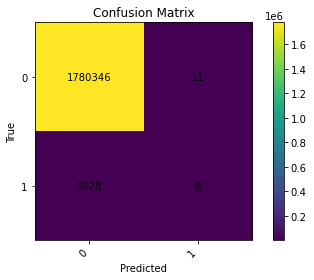

In [49]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print("Confusion Matrix:\n", cm)
# Define class names (for axis ticks)
classes = [0,1]
# Plot the confusion matrix
plt.figure()                     # Create a new figure
plt.imshow(cm)                   # Display matrix as an image
plt.title("Confusion Matrix")    # Add a title
plt.colorbar()                   # Show a colorbar legend

# Show class labels on the axes
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45, ha="right")
plt.yticks(tick_marks, classes)

# Place numeric labels inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center"
        )

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize simple decision tree classifier
dt = DecisionTreeClassifier(random_state=42)

# Fit the model
dt.fit(X_train, y_train)

# Predict on test set
y_pred = dt.predict(X_test)

# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print("Confusion Matrix:\n", cm)

Accuracy: 0.999437462738216
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1780357
           1       0.81      0.81      0.81      2636

    accuracy                           1.00   1782993
   macro avg       0.90      0.91      0.91   1782993
weighted avg       1.00      1.00      1.00   1782993

Confusion Matrix:
 [[1779848     509]
 [    494    2142]]


Confusion Matrix:
 [[1779848     509]
 [    494    2142]]


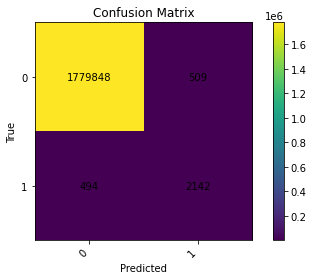

In [57]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print("Confusion Matrix:\n", cm)
# Define class names (for axis ticks)
classes = [0,1]
# Plot the confusion matrix
plt.figure()                     # Create a new figure
plt.imshow(cm)                   # Display matrix as an image
plt.title("Confusion Matrix")    # Add a title
plt.colorbar()                   # Show a colorbar legend

# Show class labels on the axes
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45, ha="right")
plt.yticks(tick_marks, classes)

# Place numeric labels inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center"
        )

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [58]:
from xgboost import XGBClassifier

xgb = XGBClassifier(scale_pos_weight=99.85/0.15, random_state=42)  # Adjust weight for fraud class
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print("Confusion Matrix:\n", cm)

Accuracy: 0.9936410294375805
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00   1780357
           1       0.18      0.95      0.31      2636

    accuracy                           0.99   1782993
   macro avg       0.59      0.97      0.65   1782993
weighted avg       1.00      0.99      1.00   1782993

Confusion Matrix:
 [[1769141   11216]
 [    122    2514]]


In [59]:
from lightgbm import LGBMClassifier

light = LGBMClassifier(class_weight="balanced", random_state=42)
light.fit(X_train, y_train)

y_pred = light.predict(X_test)

# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print("Confusion Matrix:\n", cm)

[LightGBM] [Info] Number of positive: 10696, number of negative: 7121274
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.134612 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3893
[LightGBM] [Info] Number of data points in the train set: 7131970, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Accuracy: 0.9832730694960664
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99   1780357
           1       0.08      0.96      0.15      2636

    accuracy                           0.98   1782993
   macro avg       0.54      0.97      0.57   1782993
weighted avg       1.00      0.98      0.99   1782993

Confusion Matrix:
 [[1750627   29730]
 [     94    2542]]


for the group we claim no 
low precision meaning high type 1 error: 92% of positive predictions are false positives — many people flagged as risky are actually not.

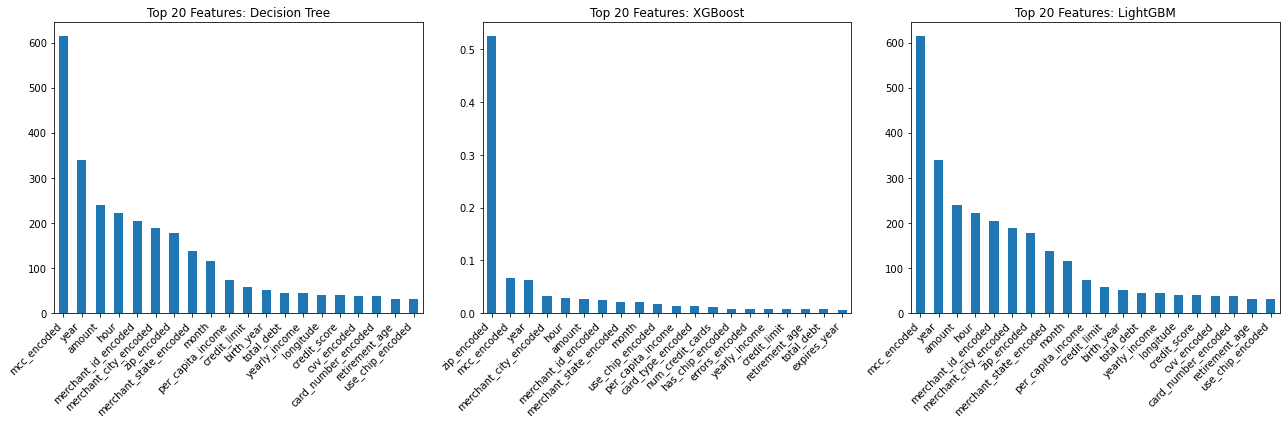

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Decision Tree Feature Importance ---
feature_importance_dt = pd.Series(clf.feature_importances_, index=X.columns)
feature_importance_dt = feature_importance_dt.sort_values(ascending=False)

# --- XGBoost Feature Importance ---
feature_importance_xgb = pd.Series(xgb.feature_importances_, index=X.columns)
feature_importance_xgb = feature_importance_xgb.sort_values(ascending=False)

# --- LightGBM Feature Importance ---
feature_importance_lgb = pd.Series(light.feature_importances_, index=X.columns)
feature_importance_lgb = feature_importance_lgb.sort_values(ascending=False)

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

# Plot Decision Tree top 20
feature_importance_dt[:20].plot(kind='bar', ax=axes[0])
axes[0].set_title("Top 20 Features: Decision Tree")

# Plot XGBoost top 20
feature_importance_xgb[:20].plot(kind='bar', ax=axes[1])
axes[1].set_title("Top 20 Features: XGBoost")

# Plot LightGBM top 20
feature_importance_lgb[:20].plot(kind='bar', ax=axes[2])
axes[2].set_title("Top 20 Features: LightGBM")

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [41]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Create a SHAP explainer
explainer = shap.TreeExplainer(clf.predict, X_test)

# Calculate SHAP values for all samples
shap_values = explainer(X_test)

# Use SHAP's summary_plot to visualize feature importance
#    (bar plot of mean absolute value of SHAP values per feature)
# plt.figure()
# shap.summary_plot(shap_values, X, max_display=20)
# plt.show()

SystemError: initialization of _internal failed without raising an exception